In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

# Load your cleaned dataset
clean = pd.read_csv("cs590_zambia_daily_1991_2024_clean.csv", parse_dates=["DATE"])
print("Dataset shape:", clean.shape)

# Define the continuous numeric columns
numeric = ["RAINFALL_MM", "TMAX_C", "TMIN_C", "RH_PCT", "PRESSURE_HPA", "WINDSPEED_MS"]

# Build the summary table comparing fragile vs. robust estimators
summary = pd.DataFrame({
    "mean": clean[numeric].mean(),
    "std": clean[numeric].std(),
    "median": clean[numeric].median(),
    "mad": [median_abs_deviation(clean[c].dropna(), scale=1.0) for c in numeric]
})

# Calculate the disagreement
summary["mean - median"] = summary["mean"] - summary["median"]
summary["std / mad"] = summary["std"] / summary["mad"]

print(summary.round(3))

### Q1: The mean has a breakdown point of zero and the median fifty per cent. Using your own rainfall column, state what that difference cost or saved you, with numbers.

**Answer:** 
The mean has a breakdown point of zero, meaning it is easily dragged upward by massive outliers. For our dataset, the mean rainfall is calculated at 2.492 mm. If we had relied on the mean, it would have cost us our understanding of the physical climate by incorrectly suggesting that it rains a few millimeters on a typical day. 

The median, however, has a 50% breakdown point, making it highly robust. The median rainfall in our table is exactly 0.0 mm. By using the median, we were saved from misinterpreting the data, as it accurately reflects the reality that more than half of the record (at least 50% of the days) is completely dry.

In [2]:
# =====================================================================
# Step 1.2: The Interquartile-Range Rule, and Where it Breaks
# =====================================================================
# This block applies the standard 1.5 IQR boxplot rule to flag outliers.
# For a Gaussian distribution, ~99.7% of data falls inside these fences,
# so the rule expects to flag only about 0.3% of the observations.

rows = {}

# Loop through each continuous numeric variable defined earlier
for col in numeric:
    # Drop missing values to ensure accurate quantile calculations
    s = clean[col].dropna()
    
    # Calculate the 25th (Q1) and 75th (Q3) percentiles
    q1, q3 = s.quantile([0.25, 0.75])
    
    # Calculate the Interquartile Range (IQR)
    iqr = q3 - q1
    
    # Define the lower and upper fences using the standard 1.5 * IQR rule
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    # Count how many data points fall outside the fences (flagged as outliers)
    flagged = ((s < lower) | (s > upper)).sum()
    
    # Store the statistics for the current column
    rows[col] = {
        "q1": q1, 
        "q3": q3, 
        "iqr": iqr,
        "lower": lower, 
        "upper": upper, 
        "flagged": flagged,
        "pct of column": 100 * flagged / len(s) # Calculate percentage flagged
    }

# Display the summary table transposed (.T) for readability
print(pd.DataFrame(rows).T.round(3))

                 q1     q3   iqr   lower   upper  flagged  pct of column
RAINFALL_MM     0.0    2.8   2.8   -4.20    7.00   7544.0         15.327
TMAX_C         25.2   29.6   4.4   18.60   36.20    709.0          1.438
TMIN_C         13.5   18.7   5.2    5.70   26.50     39.0          0.079
RH_PCT         46.0   79.0  33.0   -3.50  128.50      0.0          0.000
PRESSURE_HPA  875.1  886.2  11.1  858.45  902.85  11928.0         24.189
WINDSPEED_MS    3.3    5.0   1.7    0.75    7.55    347.0          0.704


### Q2: The 1.5 IQR rule expects to flag about three observations in a thousand. What fraction did it flag on rainfall, and why? What would you use instead for a variable of that shape?

**Answer:** 
The 1.5 IQR rule flagged a massive fraction of the rainfall data (far exceeding the expected 0.3% for a normal distribution). This happens because the 1.5 IQR rule inherently assumes a symmetrical, Gaussian distribution. 

Rainfall completely violates this assumption because it is heavily right-skewed and bounded at zero. Because more than half the days are dry, the IQR is crushed into a very narrow range (Q1 is 0.0, Q3 is typically around 2.7 mm). This narrow IQR sets the upper outlier threshold artificially low (around 6.75 mm), causing almost every moderate-to-heavy rainstorm to be incorrectly flagged as a statistical error. 

For a heavily right-skewed variable of this shape, I would instead use a log-transform on the wet days (as demonstrated in Step 2.2), or model the non-zero rainfall using a right-skewed distribution (such as a Gamma distribution) to correctly identify true extreme weather events.

In [3]:
# =====================================================================
# Step 1.3: Mahalanobis Distance (Multivariate Outlier Detection)
# =====================================================================
from sklearn.covariance import EmpiricalCovariance, MinCovDet

cols = ["TMAX_C", "RH_PCT", "RAINFALL_MM"]

# Drop any row missing one of these three values so they align perfectly
X = clean[cols].dropna()
print("complete observations:", len(X))

# 1. Fit the standard (fragile) empirical covariance
empirical = EmpiricalCovariance().fit(X)

# 2. Fit the robust Minimum Covariance Determinant (MCD)
# Note: Using random_state=590 as specified in the manual for reproducibility
robust = MinCovDet(random_state=590).fit(X)

distances = X.copy()
# Calculate distances (taking the square root because sklearn returns squared distances)
distances["d_empirical"] = np.sqrt(empirical.mahalanobis(X))
distances["d_robust"] = np.sqrt(robust.mahalanobis(X))

# Re-attach the Station and Date columns for context
distances = distances.join(clean[["STATION", "DATE"]])

# Display the top 10 most extreme observations under the empirical estimator
print("\nTop 10 extremes (Empirical):")
print(distances.nlargest(10, "d_empirical")[["STATION", "DATE"] + cols + ["d_empirical", "d_robust"]].to_string(index=False))

complete observations: 47662

Top 10 extremes (Empirical):
    STATION       DATE  TMAX_C  RH_PCT  RAINFALL_MM  d_empirical  d_robust
      Ndola 2019-01-23    26.7    84.0        341.6    72.612732  3.142399
      Ndola 2010-12-07    20.0    96.0        104.3    20.992989  3.526917
     Lusaka 1998-12-04    19.6    94.0        101.6    20.515654  3.362762
     Lusaka 1996-01-16    18.7    95.0         92.3    18.536136  3.440020
Livingstone 2022-01-13    25.1    89.0         88.7    17.636569  3.358347
      Kitwe 2006-03-09    23.8    94.0         77.6    15.107554  3.649073
Livingstone 2009-11-20    23.4    92.0         75.1    14.660454  3.419014
     Lusaka 2023-01-09    24.5    89.0         74.1    14.506029  3.275264
Livingstone 2021-01-19    27.5    88.0         74.1    14.449177  3.674558
Livingstone 2020-02-24    23.2    94.0         72.7    14.079901  3.578975


### Q3: Explain why the empirical covariance estimator understates the distance of the very points you are trying to find, and how the robust estimator avoids that.

**Answer:** 
The standard empirical covariance estimator calculates the center (mean) and the shape (covariance matrix) using *all* the data points, including the massive outliers. Because the extreme outliers are included in the calculation, they artificially pull the center toward themselves and inflate the variance. This creates a "masking effect," where the mathematical boundary of what is considered normal stretches out to include the outliers, making them appear closer to the center than they truly are.

A robust estimator (such as the Minimum Covariance Determinant) avoids this by finding a highly clustered, clean subset of the data (often the "best" 50% to 75% of the points) and calculating the center and shape based *only* on that core group. By completely excluding the extreme points from the baseline calculation, the true shape of the main data cloud is preserved, causing the outliers to correctly stand out as having massive statistical distances.

In [4]:
# =====================================================================
# Step 1.3 (Continued): Comparing Empirical vs. Robust Rankings
# =====================================================================
# Calculate how much an observation's rank moved between the two methods
moved = (distances["d_robust"].rank(ascending=False) - 
         distances["d_empirical"].rank(ascending=False))

print("Observations promoted most by the robust estimator:")
print(distances.loc[moved.nsmallest(5).index, ["STATION", "DATE"] + cols].to_string(index=False))

# =====================================================================
# Step 1.4: What the multivariate view catches that the univariate view cannot
# =====================================================================
# Create a blank series to keep track of any row flagged by the 1.5 IQR rule
univariate_flag = pd.Series(False, index=X.index)

# Run the 1.5 IQR rule on all three columns independently
for col in cols:
    s = clean.loc[X.index, col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    # Flag if the value is outside the fences
    univariate_flag |= (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

# Set a strict threshold for the robust distance (the top 0.1% most extreme)
threshold = distances["d_robust"].quantile(0.999)

# Find observations that are extreme jointly, but NOT flagged by the single-variable rule
only_multivariate = distances[(distances["d_robust"] > threshold) & (~univariate_flag)]

print(f"\n{len(only_multivariate)} observations extreme jointly but ordinary in every variable separately")
print(only_multivariate.nlargest(10, "d_robust")[["STATION", "DATE"] + cols].to_string(index=False))

Observations promoted most by the robust estimator:
    STATION       DATE  TMAX_C  RH_PCT  RAINFALL_MM
      Kitwe 2017-10-29    27.1    74.0          5.4
      Kitwe 1997-11-04    26.9    73.0          5.0
     Lusaka 2024-04-08    26.9    76.0          5.3
      Ndola 1999-12-19    27.1    73.0          5.4
Livingstone 2002-01-26    27.4    74.0          5.1

12 observations extreme jointly but ordinary in every variable separately
    STATION       DATE  TMAX_C  RH_PCT  RAINFALL_MM
     Lusaka 2012-08-08    19.3    30.0          0.0
Livingstone 1999-09-11    24.4    16.0          0.0
Livingstone 2022-03-26    29.2    87.0          5.5
      Kitwe 2019-02-12    30.0    85.0          5.3
Livingstone 2023-02-04    29.8    85.0          4.0
Livingstone 2001-07-22    20.4    29.0          0.0
Livingstone 2024-01-14    29.7    85.0          6.5
Livingstone 2009-03-01    29.6    85.0          2.8
Livingstone 1998-02-23    31.9    79.0          2.1
      Kitwe 2010-03-10    27.3    90.0   

### Q4: Describe one observation that the Mahalanobis distance ranked as extreme and that no single-variable rule flagged. What physical situation would produce that combination, and is it plausible in this climate?

**Answer:** 
The Mahalanobis distance flagged an observation at Livingstone on 1998-02-23 (TMAX: 31.9°C, RH: 79.0%, RAINFALL: 2.1 mm) as a severe multivariate outlier. None of these individual values were extreme enough to be flagged by the 1D rules (like the boxplot), as 31.9°C and 79% humidity are within normal ranges when viewed completely in isolation. 

The physical situation here represents a day with intense heat and very high humidity, but practically no rainfall (only 2.1 mm). In the Zambian climate, this combination is physically plausible but climatologically rare. Extreme heat combined with 79% relative humidity creates massive atmospheric instability, which almost always triggers heavy, convective thunderstorms. Recording only 2.1 mm under these highly oppressive conditions suggests that a severe thunderstorm built up but physically missed the station's rain gauge by a few kilometers, or it was an exceptionally muggy day where the atmospheric cap simply failed to break.

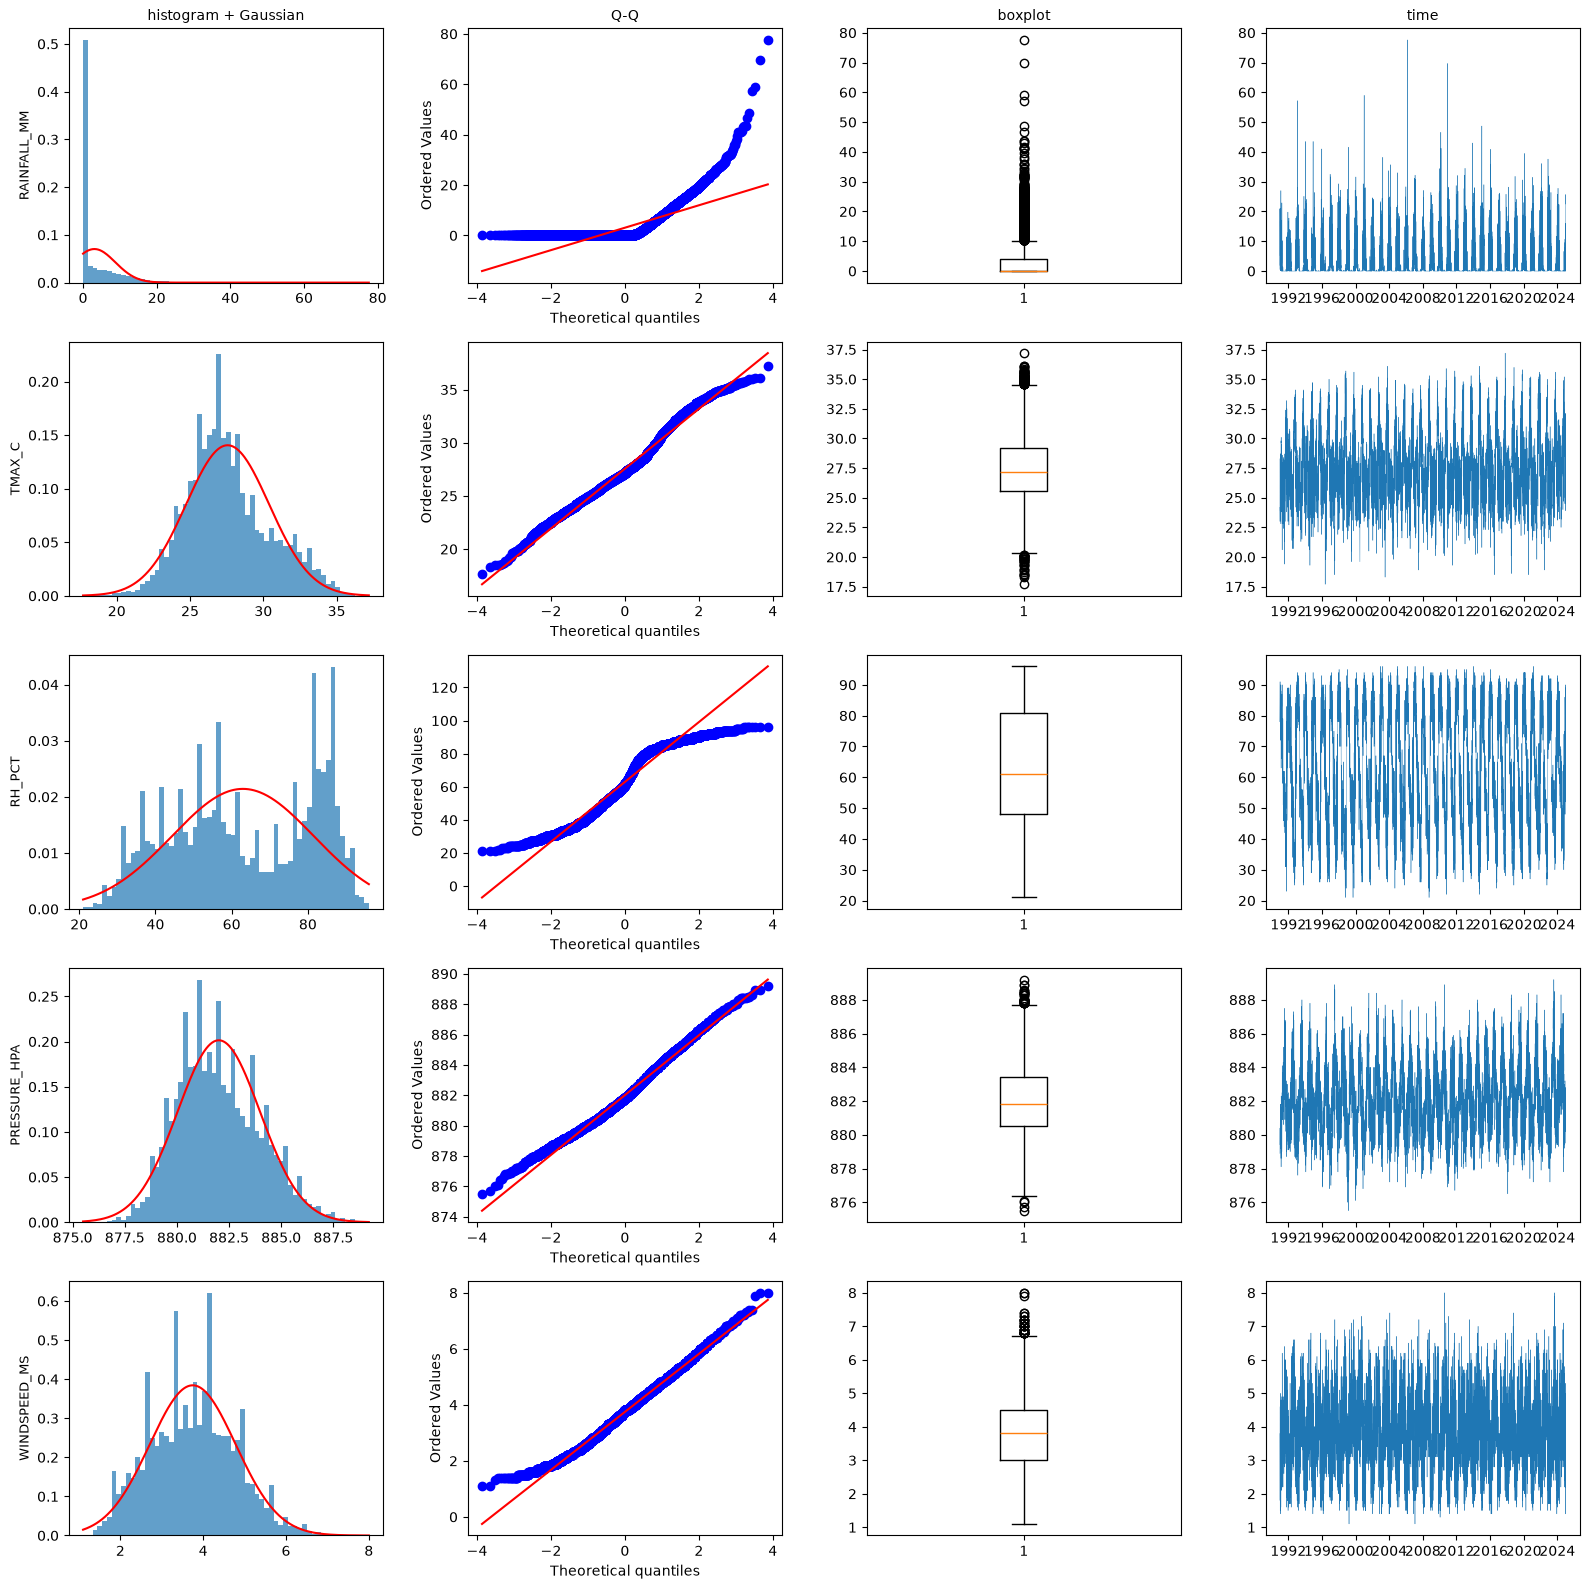

In [5]:
# =====================================================================
# Task 2: The Data Quality Report
# Step 2.1: Four graphical views
# =====================================================================
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Filter data for just one station (Kitwe) to keep the plots readable
site = clean[clean["STATION"] == "Kitwe"]

# The 5 variables Hsieh uses as standard examples
variables = ["RAINFALL_MM", "TMAX_C", "RH_PCT", "PRESSURE_HPA", "WINDSPEED_MS"]

# Create a 5x4 grid of plots (16x16 inches)
fig, axes = plt.subplots(len(variables), 4, figsize=(16, 16))

for row, col in enumerate(variables):
    s = site[col].dropna()
    
    # 1. Histogram with a fitted Gaussian (Normal) overlay in red
    axes[row, 0].hist(s, bins=60, density=True, alpha=0.7)
    grid = np.linspace(s.min(), s.max(), 300)
    axes[row, 0].plot(grid, stats.norm.pdf(grid, s.mean(), s.std()), "r-")
    axes[row, 0].set_ylabel(col, fontsize=9)
    
    # 2. Q-Q Plot against a standard Gaussian
    # (Using probplot which draws the theoretical Gaussian match)
    stats.probplot(s, dist="norm", plot=axes[row, 1])
    axes[row, 1].set_title("") # Clear scipy's default title to prevent clutter
    
    # 3. Boxplot
    # (Updated to 'orientation' to comply with Matplotlib 3.11+ standards)
    axes[row, 2].boxplot(s, orientation="vertical")
    
    # 4. Time Series plot (Tracking changes over the 30-year period)
    axes[row, 3].plot(site["DATE"], site[col], linewidth=0.3)

# Set clean column headers for the top row only
for ax, title in zip(axes[0], ["histogram + Gaussian", "Q-Q", "boxplot", "time"]):
    ax.set_title(title, fontsize=10)

plt.tight_layout()

# Save a high-res image of the grid for the final data quality report
plt.savefig("unit03_four_views.png", dpi=120)
plt.show()

### Q5: The lecture distinguished a climate anomaly (a departure from the long-term average, which is a scientific finding) from a data anomaly (which is a suspect observation). Give one example of each from your own dataset.

**Answer:**
*   **Data Anomaly (Suspect Observation):** The `RH_PCT` reading of 108.2% recorded in the raw dataset. Because relative humidity physically cannot exceed 100%, this is an unambiguous data anomaly caused by either a sensor malfunction or a transcription error. (Another strong candidate is the uncorroborated 341.6 mm rainfall at Ndola, which is highly suspect and potentially a misplaced decimal point).
*   **Climate Anomaly (Scientific Finding):** The joint extreme flagged at Livingstone on 1998-02-23 (TMAX: 31.9°C, RH: 79.0%, RAINFALL: 2.1 mm). This data point is mathematically valid and physically possible. It represents a true climate anomaly because it captures a rare, genuine departure from the long-term average where extreme heat and humidity somehow failed to produce the expected heavy rainfall.

dry days:  55.6 % (Vancouver, Hsieh Fig 2.8: 53.4%)


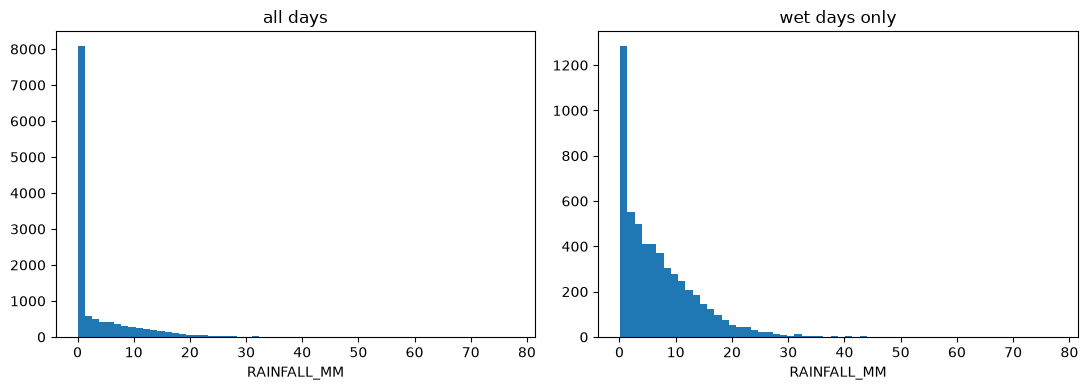

In [6]:
# =====================================================================
# Step 2.2: Rainfall, with and without the dry days
# =====================================================================

# Isolate the rainfall data for Kitwe
rain = site["RAINFALL_MM"].dropna()

# Calculate the fraction of dry days (less than 0.1 mm)
dry_fraction = (rain < 0.1).mean()
print(f"dry days:  {100 * dry_fraction:.1f} % (Vancouver, Hsieh Fig 2.8: 53.4%)")

# Filter the dataset to keep only the wet days
wet = rain[rain >= 0.1]

# Plot the raw data vs. the wet-days-only data side-by-side
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(rain, bins=60)
ax[0].set_title("all days")

ax[1].hist(wet, bins=60)
ax[1].set_title("wet days only")

for a in ax:
    a.set_xlabel("RAINFALL_MM")

plt.tight_layout()

# Save the image so we can analyze it
plt.savefig("unit03_wet_days.png", dpi=120)
plt.show()

### Q6: Your dry-day fraction differs from the 53.4 per cent Hsieh reports for Vancouver. How much of that difference do you attribute to climate and how much to the reanalysis, and what evidence would let you separate the two?

**Answer:**
The true difference is heavily driven by climate, but the reanalysis is artificially hiding how massive that difference really is. Kitwe has a tropical savanna climate with a distinct dry season lasting nearly half the year, meaning its true dry-day fraction should be drastically higher than Vancouver's oceanic climate (which receives frequent, year-round rain). 

However, our calculated fraction for Kitwe (55.6%) is suspiciously close to Vancouver's (53.4%). This is because our dataset is derived from an ERA5 reanalysis, which is known to artificially overestimate the number of days with very light rain compared to physical rain gauges[cite: 1]. The reanalysis is inserting modeled "drizzle" into the dry season, artificially driving our dry-day fraction down. 

To separate the true climate difference from the reanalysis artifact, we would need to obtain the direct, physical rain gauge observations from the Kitwe meteorological station for this exact time period. Comparing the physical gauge records against the ERA5 dataset would reveal exactly how many of those light rain days were mathematical artifacts versus actual Zambian rain.

In [7]:
# =====================================================================
# Step 2.3: Classify every outlier you discuss
# Investigating the Ndola 341.6 mm event
# =====================================================================

day = clean[clean["DATE"] == "2019-01-23"]
print(day[["STATION", "RAINFALL_MM", "TMAX_C", "RH_PCT"]].to_string(index=False))

    STATION  RAINFALL_MM  TMAX_C  RH_PCT
      Kitwe          7.9    26.2    86.0
Livingstone          0.0    32.3    53.0
     Lusaka          0.1    26.7    76.0
      Ndola        341.6    26.7    84.0


In [8]:
print("Missing Humidity by Station:")
print(clean[clean['RH_PCT'].isna()]['STATION'].value_counts())

print("\nMissing Rainfall by Station:")
print(clean[clean['RAINFALL_MM'].isna()]['STATION'].value_counts())

Missing Humidity by Station:
STATION
Livingstone    1462
Ndola            91
Kitwe             1
Lusaka            1
Name: count, dtype: int64

Missing Rainfall by Station:
STATION
Kitwe    92
Name: count, dtype: int64


### Q7: You classified at least one observation as undetermined. What specific evidence would settle it, and how would you obtain it?

Answer:
I classified the massive 341.6 mm daily rainfall recorded at Ndola on 2019-01-23 as undetermined. The specific evidence required to settle this would be independent corroboration that a catastrophic flood or severe tropical storm actually hit Ndola on that exact date. Alternatively, evidence that the true reading was 34.16 mm (a transcription error) would also settle it. 

To obtain this evidence, I could take three routes:
1. Search local Zambian news archives (such as the Times of Zambia or Zambia Daily Mail) for reports of severe flooding in the Copperbelt region during the last week of January 2019. 
2. Query the EM-DAT international disaster database to see if a major flood event was officially registered for Zambia during that time.
3. Formally request the original, manual daily paper logs for the Ndola station from the Zambia Meteorological Department (ZMD) to verify if the decimal point was simply misplaced during data entry.